In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
dataset=pd.read_csv("/content/Salary_Data.csv")
dataset.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
#slicing the dataset as descriptive (indepedent) and
# target variable (depedent)
x=dataset.iloc[:,0:1].values
y=dataset.iloc[:,-1].values
print(x)
print(y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)
print(dataset.shape)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
print(x_train)
print(x_test)
print(y_train)

print(y_test)

(30, 2)
(20, 1)
(10, 1)
(20,)
(10,)
[[ 2.9]
 [ 5.1]
 [ 3.2]
 [ 4.5]
 [ 8.2]
 [ 6.8]
 [ 1.3]
 [10.5]
 [ 3. ]
 [ 2.2]
 [ 5.9]
 [ 6. ]
 [ 3.7]
 [ 3.2]
 [ 9. ]
 [ 2. ]
 [ 1.1]
 [ 7.1]
 [ 4.9]
 [ 4. ]]
[[ 1.5]
 [10.3]
 [ 4.1]
 [ 3.9]
 [ 9.5]
 [ 8.7]
 [ 9.6]
 [ 4. ]
 [ 5.3]
 [ 7.9]]
[ 56642.  66029.  64445.  61111. 113812.  91738.  46205. 121872.  60150.
  39891.  81363.  93940.  57189.  54445. 105582.  43525.  39343.  98273.
  67938.  56957.]
[ 37731. 122391.  57081.  63218. 116969. 109431. 112635.  55794.  83088.
 101302.]


In [6]:
#linear regression without using inbuilt function
#calculate the mean variables of  input and output
x_mean=np.mean(x_train)
y_mean=np.mean(y_train)
print(x_mean,y_mean)

4.7299999999999995 71022.5


In [7]:
#calculate intercept and coefficient
n=len(x_train)
num,den=0,0
for i in range(n):
  num+=(x_train[i]-x_mean)*(y_train[i]-y_mean)
  den+=(x_train[i]-x_mean)**2
b1=num/den
b0=y_mean-(b1*x_mean)
print("b0:",b0)

b0: [26816.19224403]


In [8]:
#predicting results on test dataset
y_pred_code=b0*x_test
print(y_pred_code)

[[ 40224.28836605]
 [276206.78011352]
 [109946.38820053]
 [104583.14975172]
 [254753.8263183 ]
 [233300.87252307]
 [257435.4455427 ]
 [107264.76897612]
 [142125.81889337]
 [211847.91872785]]


In [9]:
print(y_test)

[ 37731. 122391.  57081.  63218. 116969. 109431. 112635.  55794.  83088.
 101302.]


In [10]:
#mean square error
n1=len(y_test)
mse=0
for i in range(n1):
  mse+=(y_test[i]-y_pred_code[i])**2
mse=mse/n1
print(mse)


[1.01822013e+10]


In [11]:
#root mean square error
rmse=np.sqrt(mse)
print(rmse)


[100906.89399652]


In [12]:
#create an object of the algorithm / model
from sklearn.linear_model import LinearRegression
reg=LinearRegression()


In [13]:
# train the model
reg.fit(x_train,y_train)

LinearRegression()

In [14]:
# predict the model on testing dataset
y_pred=reg.predict(x_test)
print(y_pred)

[ 40835.10590871 123079.39940819  65134.55626083  63265.36777221
 115602.64545369 108125.8914992  116537.23969801  64199.96201652
  76349.68719258 100649.1375447 ]


In [15]:
#calculate intercept and coefficient
print("intercept:",reg.intercept_)
print("coefficient:",reg.coef_	)



intercept: 26816.192244031183
coefficient: [9345.94244312]


In [16]:
#evaluation metrics
from sklearn import metrics
print("Mean absolute error:",metrics.mean_absolute_error(y_test,y_pred))

Mean absolute error: 3426.4269374307078


In [17]:
from sklearn import metrics
print("Mean absolute error:")
print(metrics.mean_absolute_error(y_test,y_pred))

Mean absolute error:
3426.4269374307078


In [18]:
#evaluation metrics
from sklearn import metrics
print("mean absolute error:",metrics.mean_absolute_error(y_test,y_pred))
print("mean squared error:",metrics.mean_squared_error(y_test,y_pred))
print("root mean squared error:",np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

mean absolute error: 3426.4269374307078
mean squared error: 21026037.329511296
root mean squared error: 4585.4157204675885


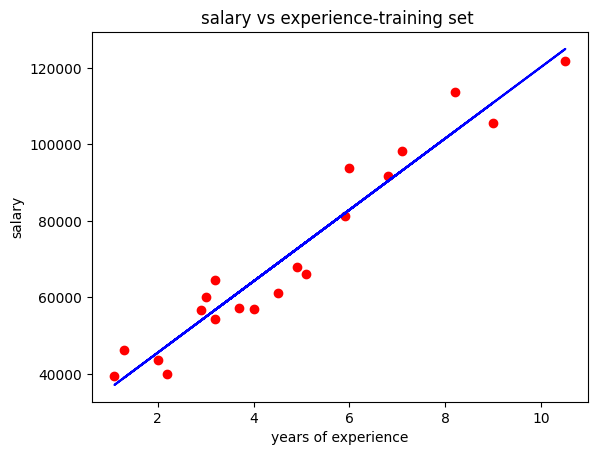

In [19]:
#visualisation
plt.scatter(x_train,y_train,color="red")
plt.plot(x_train,reg.predict(x_train),color="blue")
plt.title("salary vs experience-training set ")
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.show()

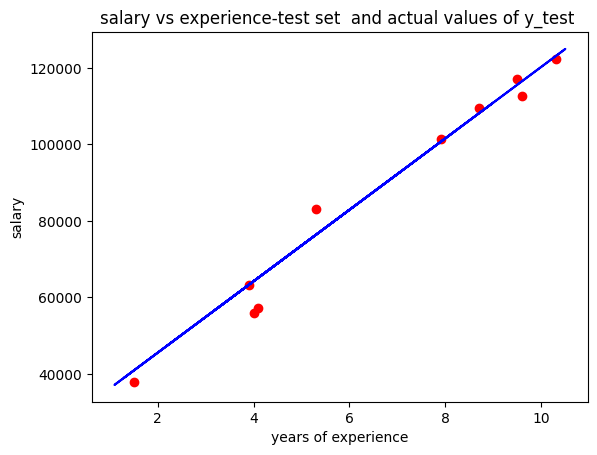

In [20]:
#visualisation
plt.scatter(x_test,y_test,color="red")
plt.plot(x_train,reg.predict(x_train),color="blue")
plt.title("salary vs experience-test set  and actual values of y_test ")
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.show()

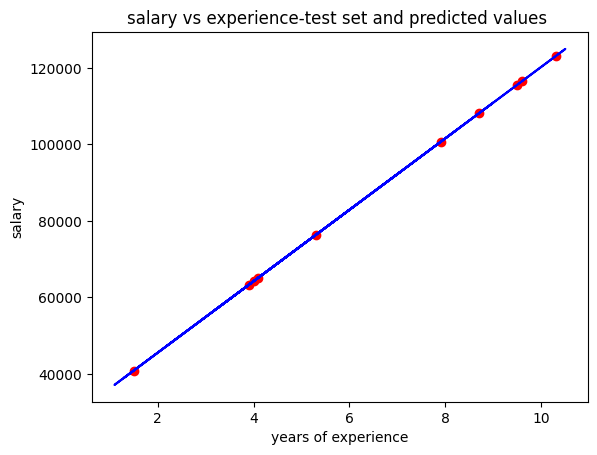

In [23]:
#visualisation
plt.scatter(x_test,y_pred,color="red")
plt.plot(x_train,reg.predict(x_train),color="blue")
plt.title("salary vs experience-test set and predicted values ")
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.show()